In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [9]:
df_apple = pd.read_csv('../Dataset/Apple.csv')
df_microsoft = pd.read_csv('../Dataset/Microsoft.csv')
df_google = pd.read_csv('../Dataset/Google.csv')
df_amazon = pd.read_csv('../Dataset/Amazon.csv')
df_adobe = pd.read_csv('../Dataset/Adobe.csv')
df_meta = pd.read_csv('../Dataset/Meta.csv')
df_nvidia = pd.read_csv('../Dataset/NVIDIA.csv')
df_salesforce = pd.read_csv('../Dataset/Salesforce.csv')


In [ ]:
df = pd.concat([df_apple[["Date",'Close']], df_microsoft[["Date",'Close']], df_google[["Date",'Close']], df_amazon[["Date",'Close']], df_adobe[["Date",'Close']], df_meta[["Date",'Close']], df_nvidia[["Date",'Close']], df_salesforce[["Date",'Close']]], axis=1,)
df.columns = ['Date_Apple','Close_Apple', 'Date_Microsoft','Close_Microsoft', 'Date_Google','Close_Google', 'Date_Amazon','Close_Amazon', 'Date_Adobe','Close_Adobe', 'Date_Meta','Close_Meta', 'Date_NVIDIA','Close_NVIDIA', 'Date_Salesforce','Close_Salesforce']
df.head()

,Date_Apple,Close_Apple,Date_Microsoft,Close_Microsoft,Date_Google,Close_Google,Date_Amazon,Close_Amazon,Date_Adobe,Close_Adobe,Date_Meta,Close_Meta,Date_NVIDIA,Close_NVIDIA,Date_Salesforce,Close_Salesforce
0,2021-05-17 00:00:00-04:00,123.081909,2021-05-17 00:00:00-04:00,235.264832,2021-05-17 00:00:00-04:00,113.507866,2021-05-17 00:00:00-04:00,163.519501,2021-05-17 00:00:00-04:00,482.739990,2021-05-17 00:00:00-04:00,313.003723,2021-05-17 00:00:00-04:00,14.129888,2021-05-17 00:00:00-04:00,211.948257
1,2021-05-18 00:00:00-04:00,121.697777,2021-05-18 00:00:00-04:00,233.249756,2021-05-18 00:00:00-04:00,112.196198,2021-05-18 00:00:00-04:00,161.613998,2021-05-18 00:00:00-04:00,480.619995,2021-05-18 00:00:00-04:00,307.546478,2021-05-18 00:00:00-04:00,13.980512,2021-05-18 00:00:00-04:00,211.228836
2,2021-05-19 00:00:00-04:00,121.541817,2021-05-19 00:00:00-04:00,233.826797,2021-05-19 00:00:00-04:00,112.644012,2021-05-19 00:00:00-04:00,161.589996,2021-05-19 00:00:00-04:00,480.470001,2021-05-19 00:00:00-04:00,311.148254,2021-05-19 00:00:00-04:00,14.030388,2021-05-19 00:00:00-04:00,218.137390
3,2021-05-20 00:00:00-04:00,124.095665,2021-05-20 00:00:00-04:00,237.058395,2021-05-20 00:00:00-04:00,114.401985,2021-05-20 00:00:00-04:00,162.384003,2021-05-20 00:00:00-04:00,491.670013,2021-05-20 00:00:00-04:00,316.129211,2021-05-20 00:00:00-04:00,14.575763,2021-05-20 00:00:00-04:00,220.542068
4,2021-05-21 00:00:00-04:00,122.263138,2021-05-21 00:00:00-04:00,235.798431,2021-05-21 00:00:00-04:00,113.766228,2021-05-21 00:00:00-04:00,160.154007,2021-05-21 00:00:00-04:00,488.070007,2021-05-21 00:00:00-04:00,313.767731,2021-05-21 00:00:00-04:00,14.954060,2021-05-21 00:00:00-04:00,219.359451


In [13]:
df = df[["Date_Apple", 'Close_Apple', 'Close_Microsoft', 'Close_Google', 'Close_Amazon', 'Close_Adobe', 'Close_Meta', 'Close_NVIDIA', 'Close_Salesforce']]
df.head()

,Date_Apple,Close_Apple,Close_Microsoft,Close_Google,Close_Amazon,Close_Adobe,Close_Meta,Close_NVIDIA,Close_Salesforce
0,2021-05-17 00:00:00-04:00,123.081909,235.264832,113.507866,163.519501,482.739990,313.003723,14.129888,211.948257
1,2021-05-18 00:00:00-04:00,121.697777,233.249756,112.196198,161.613998,480.619995,307.546478,13.980512,211.228836
2,2021-05-19 00:00:00-04:00,121.541817,233.826797,112.644012,161.589996,480.470001,311.148254,14.030388,218.137390
3,2021-05-20 00:00:00-04:00,124.095665,237.058395,114.401985,162.384003,491.670013,316.129211,14.575763,220.542068
4,2021-05-21 00:00:00-04:00,122.263138,235.798431,113.766228,160.154007,488.070007,313.767731,14.954060,219.359451


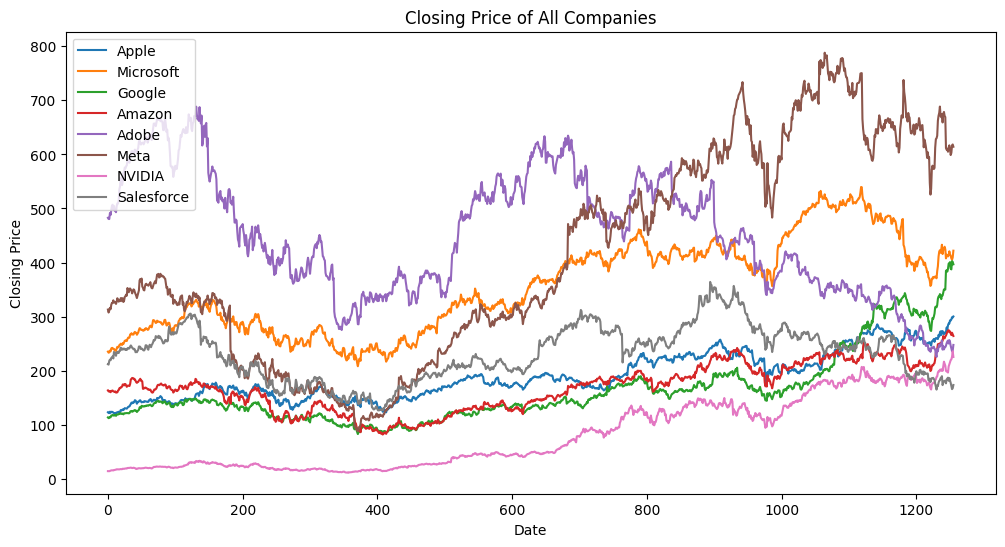

In [16]:
df.Close_Apple.plot(figsize=(12,6),label="Apple")
df.Close_Microsoft.plot(figsize=(12,6),label="Microsoft")
df.Close_Google.plot(figsize=(12,6),label="Google")
df.Close_Amazon.plot(figsize=(12,6),label="Amazon")
df.Close_Adobe.plot(figsize=(12,6),label="Adobe")
df.Close_Meta.plot(figsize=(12,6),label="Meta")
df.Close_NVIDIA.plot(figsize=(12,6),label="NVIDIA")
df.Close_Salesforce.plot(figsize=(12,6),label="Salesforce")
plt.legend()
plt.title("Closing Price of All Companies")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.savefig("../Visualization/Closing_Price.png")
plt.show()

In [18]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

result = coint_johansen(df.drop("Date_Apple", axis=1), det_order=0, k_ar_diff=1)

print("Trace Statistics:", result.lr1)
print("Max Eigenvalue Statistics:", result.lr2)
print("Critical Values (Trace):", result.cvt)
print("Critical Values (Max Eigenvalue):", result.cvm)   

Trace Statistics: [151.19261688 106.52570439  70.2712099   43.65358498  23.28355982
  12.48845585   6.21984019   2.29640827]
Max Eigenvalue Statistics: [44.66691249 36.25449449 26.61762492 20.37002516 10.79510397  6.26861566
  3.92343192  2.29640827]
Critical Values (Trace): [[153.6341 159.529  171.0905]
 [120.3673 125.6185 135.9825]
 [ 91.109   95.7542 104.9637]
 [ 65.8202  69.8189  77.8202]
 [ 44.4929  47.8545  54.6815]
 [ 27.0669  29.7961  35.4628]
 [ 13.4294  15.4943  19.9349]
 [  2.7055   3.8415   6.6349]]
Critical Values (Max Eigenvalue): [[49.2855 52.3622 58.6634]
 [43.2947 46.2299 52.3069]
 [37.2786 40.0763 45.8662]
 [31.2379 33.8777 39.3693]
 [25.1236 27.5858 32.7172]
 [18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [24]:
result.cvm.shape

(8, 3)

In [25]:
df.columns

Index(['Date_Apple', 'Close_Apple', 'Close_Microsoft', 'Close_Google',
       'Close_Amazon', 'Close_Adobe', 'Close_Meta', 'Close_NVIDIA',
       'Close_Salesforce'],
      dtype='str')

In [26]:
from statsmodels.tsa.vector_ar.vecm import VECM

In [27]:
vecm = VECM(df.drop("Date_Apple", axis=1), k_ar_diff=1, coint_rank=1, deterministic='ci')

In [28]:
vecm_fitted = vecm.fit()

# Step 3: Extract Hedge Ratios (β - cointegrating vector)
beta = vecm_fitted.beta
print("Hedge Ratios (β):")
print(pd.DataFrame(beta, index=df.drop("Date_Apple", axis=1).columns, columns=['Cointegrating_Vector']))

# Step 4: Extract Adjustment Speeds (α - loading matrix)
alpha = vecm_fitted.alpha
print("\nAdjustment Speeds (α):")
print(pd.DataFrame(alpha, index=df.drop("Date_Apple", axis=1).columns, columns=['Speed']))

Hedge Ratios (β):
                  Cointegrating_Vector
Close_Apple                   1.000000
Close_Microsoft              -0.600509
Close_Google                 -0.090173
Close_Amazon                 -1.497657
Close_Adobe                   0.110782
Close_Meta                    0.402664
Close_NVIDIA                 -0.339602
Close_Salesforce              0.131067

Adjustment Speeds (α):
                     Speed
Close_Apple      -0.007457
Close_Microsoft   0.004476
Close_Google     -0.011772
Close_Amazon      0.000425
Close_Adobe       0.008843
Close_Meta       -0.008315
Close_NVIDIA     -0.003166
Close_Salesforce  0.007818


In [29]:
spread = df.drop("Date_Apple", axis=1) @ beta  # Portfolio = weighted sum of log prices
spread = spread.values.flatten()

# Step 6: Generate Trading Signal
spread_mean = spread.mean()
spread_std = spread.std()
z_score = (spread - spread_mean) / spread_std

# Trading Rule: Buy spread when z < -2, Sell when z > 2
position = np.where(z_score < -2, 1, np.where(z_score > 2, -1, 0))

print(f"\nSpread Mean: {spread_mean:.6f}")
print(f"Spread Std: {spread_std:.6f}")
print(f"Current Z-Score: {z_score[-1]:.2f}")
print(f"Position: {position[-1]} (1=Long basket, -1=Short basket, 0=Flat)")




Spread Mean: -72.192347
Spread Std: 34.601680
Current Z-Score: -2.64
Position: 1 (1=Long basket, -1=Short basket, 0=Flat)
